# GLOBAL LITERACY & EDUCATION TRENDS

In [1]:
#Load all 5 downloaded CSVs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

so = {'User-Agent': 'Our World In Data data fetch/1.0'}

df_adult  = pd.read_csv('adult_literacy_raw.csv')
df_youth  = pd.read_csv('youth_literacy_raw.csv')
df_illit  = pd.read_csv('illiteracy_pop_raw.csv')
df_gdp    = pd.read_csv('gdp_per_capita_raw.csv')
df_school = pd.read_csv('years_schooling_raw.csv')

print("All 5 datasets loaded in Jupyter!")
print(f"Adult literacy  : {df_adult.shape}")
print(f"Youth literacy  : {df_youth.shape}")
print(f"Illiteracy pop  : {df_illit.shape}")
print(f"GDP per capita  : {df_gdp.shape}")
print(f"Years schooling : {df_school.shape}")

All 5 datasets loaded in Jupyter!
Adult literacy  : (1725, 4)
Youth literacy  : (2002, 6)
Illiteracy pop  : (2059, 5)
GDP per capita  : (7240, 5)
Years schooling : (5365, 7)


# Data Cleaning & Merging

In [3]:
#Check all column names before cleaning
for name, df in [("Adult Literacy",  df_adult),
                  ("Youth Literacy",  df_youth),
                  ("Illiteracy Pop",  df_illit),
                  ("GDP per Capita",  df_gdp),
                  ("Years Schooling", df_school)]:
    print(f"\n {name} columns:")
    for col in df.columns:
        print(f"  {col}")


 Adult Literacy columns:
  entity
  code
  year
  adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99

 Youth Literacy columns:
  entity
  code
  year
  youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m
  youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f
  owid_region

 Illiteracy Pop columns:
  entity
  code
  year
  illiteracy_rate
  literacy_rate

 GDP per Capita columns:
  entity
  code
  year
  ny_gdp_pcap_pp_kd
  owid_region

 Years Schooling columns:
  entity
  code
  year
  literacy_rate
  mf_youth_and_adults__15_64_years__average_years_of_education
  population_historical
  owid_region


In [5]:
#Rename all columns to clean readable names

# Adult Literacy
df_adult = df_adult.rename(columns={
    'entity': 'country',
    'code':   'country_code',
    'year':   'year',
    'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99': 'adult_literacy_rate'
})

# Youth Literacy
df_youth = df_youth.rename(columns={
    'entity': 'country',
    'code':   'country_code',
    'year':   'year',
    'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m':   'youth_literacy_male',
    'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f': 'youth_literacy_female',
    'owid_region': 'region'
})

# Illiteracy Population
df_illit = df_illit.rename(columns={
    'entity':          'country',
    'code':            'country_code',
    'year':            'year',
    'illiteracy_rate': 'illiteracy_rate',
    'literacy_rate':   'literacy_rate'
})

# GDP per Capita
df_gdp = df_gdp.rename(columns={
    'entity':          'country',
    'code':            'country_code',
    'year':            'year',
    'ny_gdp_pcap_pp_kd': 'gdp_per_capita',
    'owid_region':     'region'
})

# Years of Schooling
df_school = df_school.rename(columns={
    'entity':      'country',
    'code':        'country_code',
    'year':        'year',
    'literacy_rate': 'literacy_rate_school',
    'mf_youth_and_adults__15_64_years__average_years_of_education': 'avg_years_schooling',
    'population_historical': 'population',
    'owid_region': 'region'
})

print("All columns renamed successfully!")
print("\nNew column names:")
for name, df in [("Adult",    df_adult),
                  ("Youth",    df_youth),
                  ("Illit",    df_illit),
                  ("GDP",      df_gdp),
                  ("Schooling",df_school)]:
    print(f"  {name:10s}: {list(df.columns)}")

All columns renamed successfully!

New column names:
  Adult     : ['country', 'country_code', 'year', 'adult_literacy_rate']
  Youth     : ['country', 'country_code', 'year', 'youth_literacy_male', 'youth_literacy_female', 'region']
  Illit     : ['country', 'country_code', 'year', 'illiteracy_rate', 'literacy_rate']
  GDP       : ['country', 'country_code', 'year', 'gdp_per_capita', 'region']
  Schooling : ['country', 'country_code', 'year', 'literacy_rate_school', 'avg_years_schooling', 'population', 'region']


In [9]:
#Filter to 1990–2026
df_adult  = df_adult [(df_adult ['year'] >= 1990) & (df_adult ['year'] <= 2026)].copy()
df_youth  = df_youth [(df_youth ['year'] >= 1990) & (df_youth ['year'] <= 2026)].copy()
df_illit  = df_illit [(df_illit ['year'] >= 1990) & (df_illit ['year'] <= 2026)].copy()
df_gdp    = df_gdp   [(df_gdp   ['year'] >= 1990) & (df_gdp   ['year'] <= 2026)].copy()
df_school = df_school[(df_school['year'] >= 1990) & (df_school['year'] <= 2026)].copy()

print("Year filter applied (1990–2026)")
print(f"  Adult    : {df_adult.shape}  | {df_adult['year'].min()}–{df_adult['year'].max()}")
print(f"  Youth    : {df_youth.shape}  | {df_youth['year'].min()}–{df_youth['year'].max()}")
print(f"  Illit    : {df_illit.shape}  | {df_illit['year'].min()}–{df_illit['year'].max()}")
print(f"  GDP      : {df_gdp.shape}  | {df_gdp['year'].min()}–{df_gdp['year'].max()}")
print(f"  Schooling: {df_school.shape}  | {df_school['year'].min()}–{df_school['year'].max()}")

Year filter applied (1990–2026)
  Adult    : (1420, 4)  | 1990–2023
  Youth    : (1697, 6)  | 1990–2023
  Illit    : (1419, 5)  | 1990–2023
  GDP      : (7240, 5)  | 1990–2024
  Schooling: (2136, 7)  | 1990–2023


In [11]:
#Remove duplicates
for df, name in [(df_adult,'adult'),(df_youth,'youth'),
                  (df_illit,'illit'),(df_gdp,'gdp'),(df_school,'school')]:
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f"  {name:10s}: removed {before - len(df)} duplicate rows | remaining: {len(df)}")

  adult     : removed 0 duplicate rows | remaining: 1420
  youth     : removed 0 duplicate rows | remaining: 1697
  illit     : removed 0 duplicate rows | remaining: 1419
  gdp       : removed 0 duplicate rows | remaining: 7240
  school    : removed 0 duplicate rows | remaining: 2136


In [13]:
#Check and handle missing values
print("Missing values BEFORE cleaning:\n")
for name, df in [("Adult",    df_adult),
                  ("Youth",    df_youth),
                  ("Illit",    df_illit),
                  ("GDP",      df_gdp),
                  ("Schooling",df_school)]:
    total = df.isnull().sum().sum()
    print(f"  {name:10s}: {total} missing values")
    print(df.isnull().sum().to_string())
    print()

# Drop rows where KEY metric is missing
df_adult.dropna (subset=['adult_literacy_rate'],                        inplace=True)
df_youth.dropna (subset=['youth_literacy_male', 'youth_literacy_female'], inplace=True)
df_illit.dropna (subset=['illiteracy_rate'],                            inplace=True)
df_gdp.dropna   (subset=['gdp_per_capita'],                             inplace=True)
df_school.dropna(subset=['avg_years_schooling'],                        inplace=True)

print("Missing key values dropped!")
print("\n Shapes after cleaning:")
for name, df in [("Adult",    df_adult),
                  ("Youth",    df_youth),
                  ("Illit",    df_illit),
                  ("GDP",      df_gdp),
                  ("Schooling",df_school)]:
    print(f"  {name:10s}: {df.shape}")

Missing values BEFORE cleaning:

  Adult     : 552 missing values
country                  0
country_code           552
year                     0
adult_literacy_rate      0

  Youth     : 1239 missing values
country                    0
country_code             564
year                       0
youth_literacy_male       77
youth_literacy_female      0
region                   598

  Illit     : 552 missing values
country              0
country_code       552
year                 0
illiteracy_rate      0
literacy_rate        0

  GDP       : 455 missing values
country             0
country_code        0
year                0
gdp_per_capita      0
region            455

  Schooling : 3631 missing values
country                    0
country_code             589
year                       0
literacy_rate_school     751
avg_years_schooling     1252
population               450
region                   589

Missing key values dropped!

 Shapes after cleaning:
  Adult     : (1420, 4)
  Youth 

## Build the 3 merged DataFrames

In [15]:
#Build df_literacy (adult + youth merged)
df_literacy = pd.merge(
    df_adult[['country','country_code','year','adult_literacy_rate']],
    df_youth[['country','country_code','year',
              'youth_literacy_male','youth_literacy_female','region']],
    on=['country','country_code','year'],
    how='outer'
)
print(f"df_literacy      : {df_literacy.shape}")
print(df_literacy.head(3))

df_literacy      : (1635, 7)
       country country_code  year  adult_literacy_rate  youth_literacy_male  \
0  Afghanistan          AFG  2011             31.00000             62.00000   
1  Afghanistan          AFG  2015             33.75384             57.73505   
2  Afghanistan          AFG  2021             37.00000             71.00000   

   youth_literacy_female region  
0               32.00000   Asia  
1               25.48416   Asia  
2               42.00000   Asia  


In [18]:
#Build df_illiteracy
df_illiteracy = df_illit[['country','country_code','year',
                           'illiteracy_rate','literacy_rate']].copy()
print(f"df_illiteracy    : {df_illiteracy.shape}")
print(df_illiteracy.head(3))

df_illiteracy    : (1419, 5)
       country country_code  year  illiteracy_rate  literacy_rate
2  Afghanistan          AFG  2011        69.000000       31.00000
3  Afghanistan          AFG  2015        66.246155       33.75384
4  Afghanistan          AFG  2021        63.000000       37.00000


In [20]:
#Build df_gdp_schooling (GDP + schooling merged)
df_gdp_schooling = pd.merge(
    df_gdp[['country','country_code','year','gdp_per_capita','region']],
    df_school[['country','country_code','year','avg_years_schooling','population']],
    on=['country','country_code','year'],
    how='outer'
)
print(f"df_gdp_schooling : {df_gdp_schooling.shape}")
print(df_gdp_schooling.head(3))

df_gdp_schooling : (7315, 7)
       country country_code  year  gdp_per_capita region  avg_years_schooling  \
0  Afghanistan          AFG  1990             NaN    NaN                 2.06   
1  Afghanistan          AFG  1995             NaN    NaN                 2.40   
2  Afghanistan          AFG  2000       1617.8264   Asia                 3.03   

   population  
0  12045664.0  
1  17065837.0  
2  20130334.0  


# Final summary of all 3 DataFrames

In [23]:
#Final summary
print("="*55)
print("FINAL CLEANED DATAFRAMES SUMMARY")
print("="*55)
for df, name in [(df_literacy,      'df_literacy'),
                  (df_illiteracy,    'df_illiteracy'),
                  (df_gdp_schooling, 'df_gdp_schooling')]:
    print(f"\n {name}")
    print(f"   Shape    : {df.shape}")
    print(f"   Columns  : {list(df.columns)}")
    print(f"   Years    : {df['year'].min()} – {df['year'].max()}")
    print(f"   Countries: {df['country'].nunique()}")
    print(f"   Nulls    : {df.isnull().sum().sum()}")

FINAL CLEANED DATAFRAMES SUMMARY

 df_literacy
   Shape    : (1635, 7)
   Columns  : ['country', 'country_code', 'year', 'adult_literacy_rate', 'youth_literacy_male', 'youth_literacy_female', 'region']
   Years    : 1990 – 2023
   Countries: 187
   Nulls    : 1422

 df_illiteracy
   Shape    : (1419, 5)
   Columns  : ['country', 'country_code', 'year', 'illiteracy_rate', 'literacy_rate']
   Years    : 1990 – 2023
   Countries: 180
   Nulls    : 552

 df_gdp_schooling
   Shape    : (7315, 7)
   Columns  : ['country', 'country_code', 'year', 'gdp_per_capita', 'region', 'avg_years_schooling', 'population']
   Years    : 1990 – 2024
   Countries: 223
   Nulls    : 13504


In [25]:
#Save cleaned DataFrames
df_literacy.to_csv('df_literacy.csv',           index=False)
df_illiteracy.to_csv('df_illiteracy.csv',       index=False)
df_gdp_schooling.to_csv('df_gdp_schooling.csv', index=False)

print("All 3 cleaned CSVs saved!")
print("   df_literacy.csv")
print("   df_illiteracy.csv")
print("   df_gdp_schooling.csv")

All 3 cleaned CSVs saved!
   df_literacy.csv
   df_illiteracy.csv
   df_gdp_schooling.csv


# Feature Engineering 

# Literacy features

In [29]:
#Feature engineering on df_literacy

# 1. Literacy Gender Gap (male - female)
df_literacy['literacy_gender_gap'] = (
    df_literacy['youth_literacy_male'] - df_literacy['youth_literacy_female']
)

# 2. Youth Literacy Average
df_literacy['youth_literacy_avg'] = (
    df_literacy['youth_literacy_male'] + df_literacy['youth_literacy_female']
) / 2

# 3. Adult vs Youth Gap
df_literacy['adult_youth_gap'] = (
    df_literacy['youth_literacy_avg'] - df_literacy['adult_literacy_rate']
)

# 4. Literacy Growth Rate (year-over-year % change per country)
df_literacy = df_literacy.sort_values(['country','year'])
df_literacy['literacy_growth_rate'] = (
    df_literacy.groupby('country')['adult_literacy_rate']
    .pct_change() * 100
)

print("df_literacy features added!")
print(f"   Shape now : {df_literacy.shape}")
print(f"   New cols  : literacy_gender_gap, youth_literacy_avg, adult_youth_gap, literacy_growth_rate")
print("\nSample:")
print(df_literacy[['country','year','adult_literacy_rate',
                    'literacy_gender_gap','youth_literacy_avg',
                    'adult_youth_gap','literacy_growth_rate']].dropna().head(5))

df_literacy features added!
   Shape now : (1635, 11)
   New cols  : literacy_gender_gap, youth_literacy_avg, adult_youth_gap, literacy_growth_rate

Sample:
       country  year  adult_literacy_rate  literacy_gender_gap  \
1  Afghanistan  2015             33.75384             32.25089   
2  Afghanistan  2021             37.00000             29.00000   
5      Albania  2008             96.00000              0.00000   
7      Albania  2011             97.00000              0.00000   
8      Albania  2012             97.00000              0.00000   

   youth_literacy_avg  adult_youth_gap  literacy_growth_rate  
1           41.609605         7.855765              8.883355  
2           56.500000        19.500000              9.617158  
5           99.000000         3.000000             -3.030303  
7           99.000000         2.000000              1.041667  
8           99.000000         2.000000              0.000000  


#  Illiteracy features

In [35]:
#Feature engineering on df_illiteracy
# Our illiteracy_rate is already a percentage.
# So we calculate additional useful features

# 1. Illiteracy percentage (already exists as illiteracy_rate)
#    Just rename for clarity
df_illiteracy['illiteracy_pct'] = df_illiteracy['illiteracy_rate']
df_illiteracy['literacy_pct']   = df_illiteracy['literacy_rate']

# 2. Illiteracy severity category
df_illiteracy['illiteracy_category'] = pd.cut(
    df_illiteracy['illiteracy_pct'],
    bins=[0, 5, 20, 40, 100],
    labels=['Very Low (<5%)', 'Low (5–20%)',
            'High (20–40%)', 'Very High (>40%)']
)

# 3. Year-over-year illiteracy change per country
df_illiteracy = df_illiteracy.sort_values(['country','year'])
df_illiteracy['illiteracy_change'] = (
    df_illiteracy.groupby('country')['illiteracy_pct']
    .diff()
)

print("df_illiteracy features added!")
print(f"   Shape now : {df_illiteracy.shape}")
print(f"   New cols  : illiteracy_pct, literacy_pct, illiteracy_category, illiteracy_change")
print("\nSample:")
print(df_illiteracy[['country','year','illiteracy_pct',
                      'illiteracy_category','illiteracy_change']].dropna().head(5))

df_illiteracy features added!
   Shape now : (1419, 9)
   New cols  : illiteracy_pct, literacy_pct, illiteracy_category, illiteracy_change

Sample:
       country  year  illiteracy_pct illiteracy_category  illiteracy_change
3  Afghanistan  2015       66.246155    Very High (>40%)          -2.753845
4  Afghanistan  2021       63.000000    Very High (>40%)          -3.246155
7      Albania  2008        4.000000      Very Low (<5%)           3.000000
8      Albania  2011        3.000000      Very Low (<5%)          -1.000000
9      Albania  2012        3.000000      Very Low (<5%)           0.000000


#  GDP & Schooling features

In [38]:
#Feature engineering on df_gdp_schooling

# 1. GDP per Schooling Year
df_gdp_schooling['gdp_per_schooling_year'] = (
    df_gdp_schooling['gdp_per_capita'] /
    df_gdp_schooling['avg_years_schooling']
)

# 2. GDP Category (income bands)
df_gdp_schooling['gdp_category'] = pd.cut(
    df_gdp_schooling['gdp_per_capita'],
    bins=[0, 2000, 10000, 30000, float('inf')],
    labels=['Low income','Lower-middle','Upper-middle','High income']
)

# 3. GDP Growth Rate (year-over-year)
df_gdp_schooling = df_gdp_schooling.sort_values(['country','year'])
df_gdp_schooling['gdp_growth_rate'] = (
    df_gdp_schooling.groupby('country')['gdp_per_capita']
    .pct_change() * 100
)

# 4. Schooling Category
df_gdp_schooling['schooling_category'] = pd.cut(
    df_gdp_schooling['avg_years_schooling'],
    bins=[0, 4, 8, 12, float('inf')],
    labels=['Very Low (<4yr)','Low (4–8yr)',
            'Medium (8–12yr)','High (>12yr)']
)

print("df_gdp_schooling features added!")
print(f"   Shape now : {df_gdp_schooling.shape}")
print(f"   New cols  : gdp_per_schooling_year, gdp_category, gdp_growth_rate, schooling_category")
print("\nSample:")
print(df_gdp_schooling[['country','year','gdp_per_capita','avg_years_schooling',
                          'gdp_per_schooling_year','gdp_category']].dropna().head(5))

df_gdp_schooling features added!
   Shape now : (7315, 11)
   New cols  : gdp_per_schooling_year, gdp_category, gdp_growth_rate, schooling_category

Sample:
        country  year  gdp_per_capita  avg_years_schooling  \
2   Afghanistan  2000       1617.8264                 3.03   
7   Afghanistan  2005       1908.1147                 3.32   
12  Afghanistan  2010       2848.5862                 3.93   
17  Afghanistan  2015       2967.6921                 4.81   
22  Afghanistan  2020       2769.6858                 5.69   

    gdp_per_schooling_year  gdp_category  
2               533.936106    Low income  
7               574.733343    Low income  
12              724.831094  Lower-middle  
17              616.983805  Lower-middle  
22              486.763761  Lower-middle  


#  Education Index 

In [41]:
#Education Index using df_literacy + df_gdp_schooling

# Merge adult literacy into gdp_schooling temporarily
temp_lit = df_literacy[['country','year','adult_literacy_rate']].dropna()

df_gdp_schooling = pd.merge(
    df_gdp_schooling,
    temp_lit,
    on=['country','year'],
    how='left'
)

# Normalize both to 0–1 scale then average
df_gdp_schooling['literacy_norm'] = (
    df_gdp_schooling['adult_literacy_rate'] / 100
)
df_gdp_schooling['schooling_norm'] = (
    df_gdp_schooling['avg_years_schooling'] /
    df_gdp_schooling['avg_years_schooling'].max()
)
df_gdp_schooling['education_index'] = (
    df_gdp_schooling['literacy_norm'] +
    df_gdp_schooling['schooling_norm']
) / 2

print("Education Index added to df_gdp_schooling!")
print("\nSample:")
print(df_gdp_schooling[['country','year','adult_literacy_rate',
                          'avg_years_schooling','education_index']].dropna().head(5))

Education Index added to df_gdp_schooling!

Sample:
         country  year  adult_literacy_rate  avg_years_schooling  \
17   Afghanistan  2015             33.75384                 4.81   
273      Armenia  2020            100.00000                10.54   
520   Bangladesh  2015             65.00000                 6.76   
525   Bangladesh  2020             75.00000                 7.23   
660       Belize  2015             90.91604                10.56   

     education_index  
17          0.343806  
273         0.883552  
520         0.570997  
525         0.638100  
660         0.838860  


#  Verify all new features

In [44]:
#Full feature summary
print("="*55)
print(" FEATURE ENGINEERING SUMMARY")
print("="*55)

print("\n df_literacy")
print(f"   Shape   : {df_literacy.shape}")
for col in ['literacy_gender_gap','youth_literacy_avg',
            'adult_youth_gap','literacy_growth_rate']:
    nulls = df_literacy[col].isna().sum()
    print(f"   {col:30s} | nulls: {nulls}")

print("\n df_illiteracy")
print(f"   Shape   : {df_illiteracy.shape}")
for col in ['illiteracy_pct','literacy_pct',
            'illiteracy_category','illiteracy_change']:
    nulls = df_illiteracy[col].isna().sum()
    print(f"   {col:30s} | nulls: {nulls}")

print("\n df_gdp_schooling")
print(f"   Shape   : {df_gdp_schooling.shape}")
for col in ['gdp_per_schooling_year','gdp_category',
            'gdp_growth_rate','schooling_category',
            'education_index']:
    nulls = df_gdp_schooling[col].isna().sum()
    print(f"    {col:30s} | nulls: {nulls}")

 FEATURE ENGINEERING SUMMARY

 df_literacy
   Shape   : (1635, 11)
   literacy_gender_gap            | nulls: 15
   youth_literacy_avg             | nulls: 15
   adult_youth_gap                | nulls: 230
   literacy_growth_rate           | nulls: 200

 df_illiteracy
   Shape   : (1419, 9)
   illiteracy_pct                 | nulls: 0
   literacy_pct                   | nulls: 0
   illiteracy_category            | nulls: 47
   illiteracy_change              | nulls: 180

 df_gdp_schooling
   Shape   : (7315, 15)
    gdp_per_schooling_year         | nulls: 6506
    gdp_category                   | nulls: 75
    gdp_growth_rate                | nulls: 287
    schooling_category             | nulls: 6431
    education_index                | nulls: 7182


#  Save updated CSVs

In [47]:
#Save all 3 updated CSVs with new features
df_literacy.to_csv('df_literacy.csv',           index=False)
df_illiteracy.to_csv('df_illiteracy.csv',       index=False)
df_gdp_schooling.to_csv('df_gdp_schooling.csv', index=False)

print(" All 3 CSVs updated with engineered features!")
print(f"\n   df_literacy      : {df_literacy.shape}")
print(f"   df_illiteracy    : {df_illiteracy.shape}")
print(f"   df_gdp_schooling : {df_gdp_schooling.shape}")
print(f"\n   Columns in df_literacy      : {list(df_literacy.columns)}")
print(f"   Columns in df_illiteracy    : {list(df_illiteracy.columns)}")
print(f"   Columns in df_gdp_schooling : {list(df_gdp_schooling.columns)}")

 All 3 CSVs updated with engineered features!

   df_literacy      : (1635, 11)
   df_illiteracy    : (1419, 9)
   df_gdp_schooling : (7315, 15)

   Columns in df_literacy      : ['country', 'country_code', 'year', 'adult_literacy_rate', 'youth_literacy_male', 'youth_literacy_female', 'region', 'literacy_gender_gap', 'youth_literacy_avg', 'adult_youth_gap', 'literacy_growth_rate']
   Columns in df_illiteracy    : ['country', 'country_code', 'year', 'illiteracy_rate', 'literacy_rate', 'illiteracy_pct', 'literacy_pct', 'illiteracy_category', 'illiteracy_change']
   Columns in df_gdp_schooling : ['country', 'country_code', 'year', 'gdp_per_capita', 'region', 'avg_years_schooling', 'population', 'gdp_per_schooling_year', 'gdp_category', 'gdp_growth_rate', 'schooling_category', 'adult_literacy_rate', 'literacy_norm', 'schooling_norm', 'education_index']


# Exploratory Data Analysis (EDA)

#  Univariate Analysis

In [51]:
# Distribution of Adult Literacy Rate

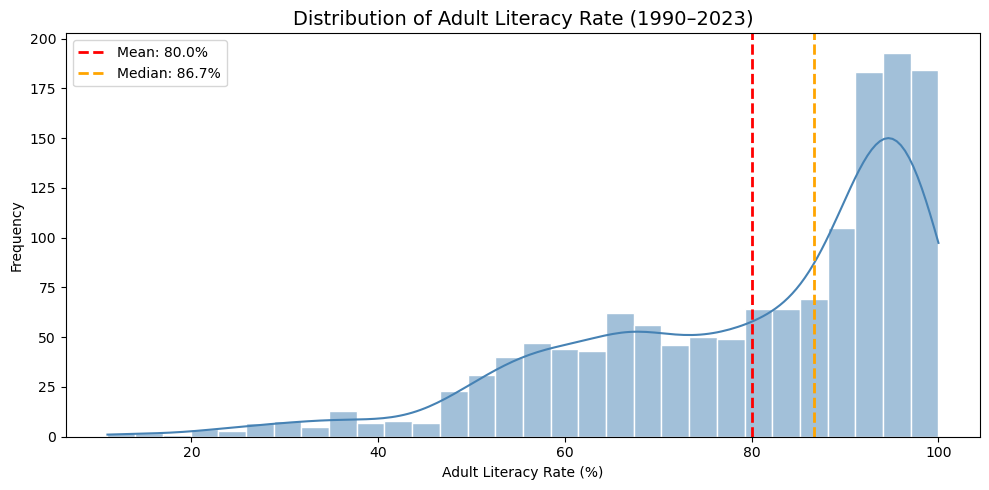

 Mean: 80.0% | Median: 86.7% | Std: 18.1%


In [81]:
#Histogram of adult literacy rate

plt.figure(figsize=(10, 5))
data = df_literacy['adult_literacy_rate'].dropna()

sns.histplot(data, bins=30, color='steelblue', edgecolor='white', kde=True)
plt.axvline(data.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {data.mean():.1f}%')
plt.axvline(data.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {data.median():.1f}%')

plt.title('Distribution of Adult Literacy Rate (1990–2023)', fontsize=14)
plt.xlabel('Adult Literacy Rate (%)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('plot1_adult_literacy_dist.png', dpi=150)
plt.show()
print(f" Mean: {data.mean():.1f}% | Median: {data.median():.1f}% | Std: {data.std():.1f}%")

In [ ]:
# Top 10 & Bottom 10 countries by adult literacy

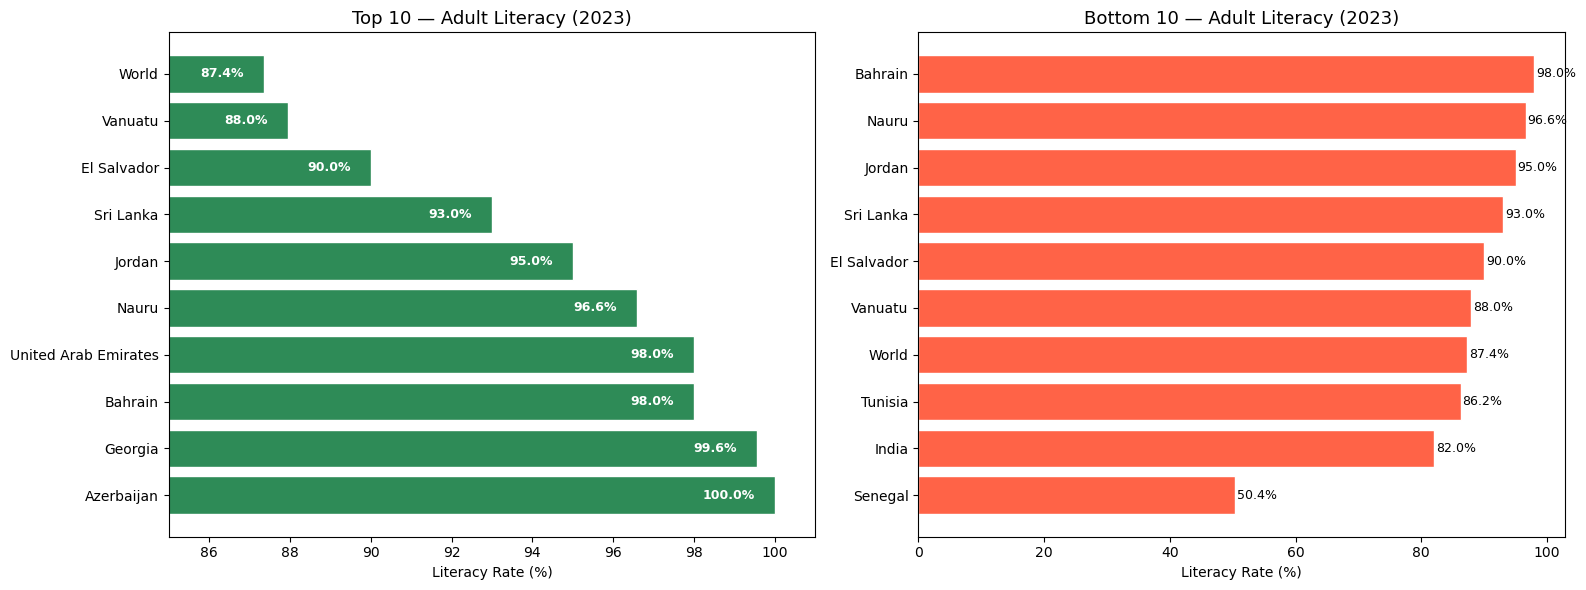

 Year used: 2023 | Top country: Azerbaijan | Bottom: Senegal


In [58]:
# Top & Bottom 10 countries
latest_year = df_literacy['year'].max()
df_latest = (df_literacy[df_literacy['year'] == latest_year]
             .dropna(subset=['adult_literacy_rate'])
             .query("country_code.notna()", engine='python'))

top10    = df_latest.nlargest(10,  'adult_literacy_rate')
bottom10 = df_latest.nsmallest(10, 'adult_literacy_rate')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
axes[0].barh(top10['country'], top10['adult_literacy_rate'],
             color='seagreen', edgecolor='white')
axes[0].set_title(f'Top 10 — Adult Literacy ({latest_year})', fontsize=13)
axes[0].set_xlabel('Literacy Rate (%)')
axes[0].set_xlim(85, 101)
for i, val in enumerate(top10['adult_literacy_rate']):
    axes[0].text(val - 0.5, i, f'{val:.1f}%', va='center',
                 ha='right', color='white', fontsize=9, fontweight='bold')

# Bottom 10
axes[1].barh(bottom10['country'], bottom10['adult_literacy_rate'],
             color='tomato', edgecolor='white')
axes[1].set_title(f'Bottom 10 — Adult Literacy ({latest_year})', fontsize=13)
axes[1].set_xlabel('Literacy Rate (%)')
for i, val in enumerate(bottom10['adult_literacy_rate']):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot2_top_bottom10.png', dpi=150)
plt.show()
print(f" Year used: {latest_year} | Top country: {top10.iloc[0]['country']} | Bottom: {bottom10.iloc[0]['country']}")

In [60]:
# GDP per capita distribution

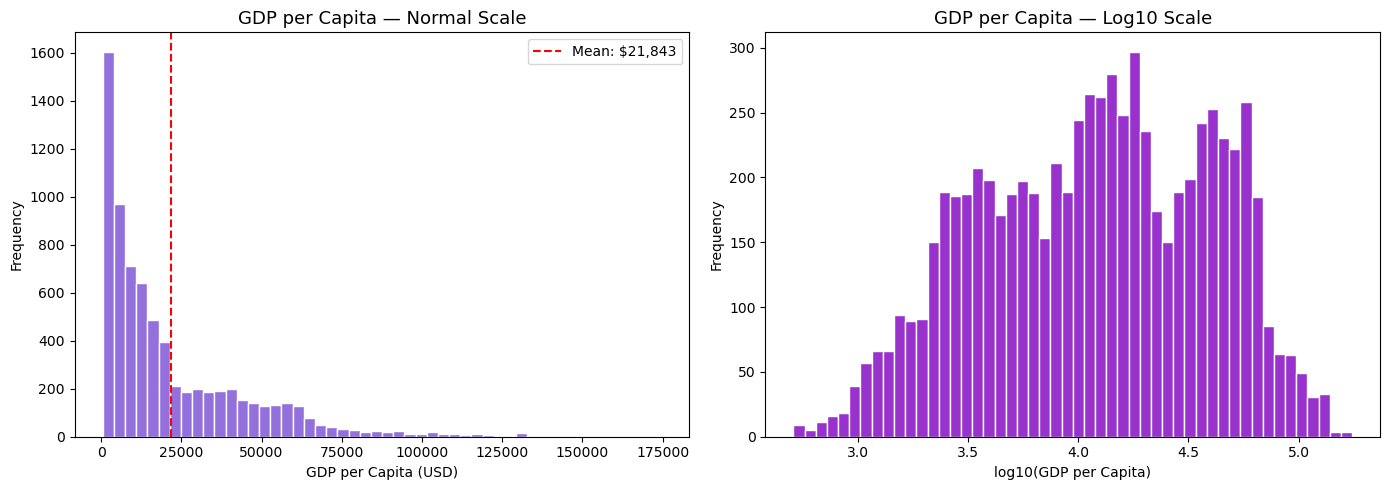

 GDP Mean: $21,843 | Median: $12,715 | Max: $174,570


In [62]:
#GDP distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gdp_data = df_gdp_schooling['gdp_per_capita'].dropna()

# Normal scale
axes[0].hist(gdp_data, bins=50, color='mediumpurple', edgecolor='white')
axes[0].set_title('GDP per Capita — Normal Scale', fontsize=13)
axes[0].set_xlabel('GDP per Capita (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(gdp_data.mean(), color='red', linestyle='--',
                label=f'Mean: ${gdp_data.mean():,.0f}')
axes[0].legend()

# Log scale
axes[1].hist(np.log10(gdp_data + 1), bins=50,
             color='darkorchid', edgecolor='white')
axes[1].set_title('GDP per Capita — Log10 Scale', fontsize=13)
axes[1].set_xlabel('log10(GDP per Capita)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('plot3_gdp_dist.png', dpi=150)
plt.show()
print(f" GDP Mean: ${gdp_data.mean():,.0f} | Median: ${gdp_data.median():,.0f} | Max: ${gdp_data.max():,.0f}")

In [64]:
#  Gender gap box plot

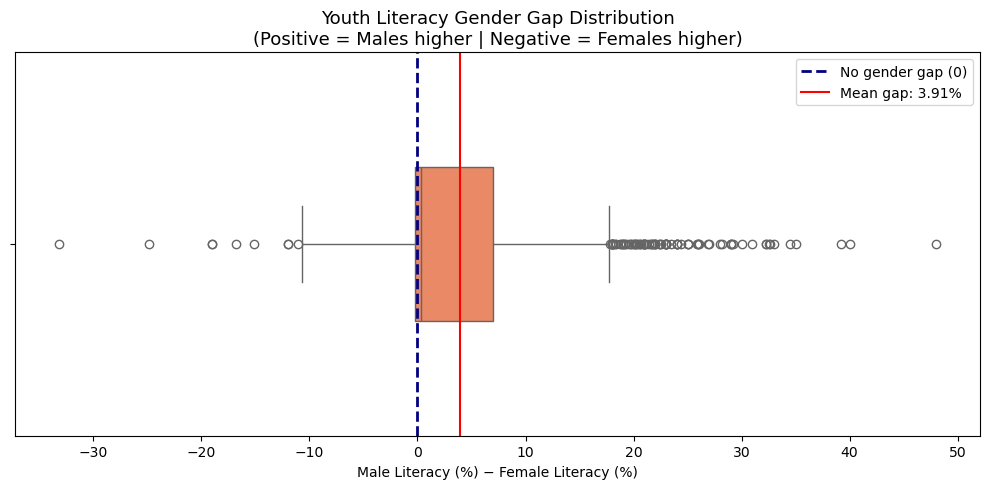

 Mean gap: 3.91% | Max: 48.00% | Min: -33.20%


In [66]:
#Gender gap distribution
plt.figure(figsize=(10, 5))
gap_data = df_literacy['literacy_gender_gap'].dropna()

sns.boxplot(x=gap_data, color='coral', width=0.4)
plt.axvline(0, color='navy', linestyle='--', linewidth=2,
            label='No gender gap (0)')
plt.axvline(gap_data.mean(), color='red', linestyle='-', linewidth=1.5,
            label=f'Mean gap: {gap_data.mean():.2f}%')

plt.title('Youth Literacy Gender Gap Distribution\n(Positive = Males higher | Negative = Females higher)',
          fontsize=13)
plt.xlabel('Male Literacy (%) − Female Literacy (%)')
plt.legend()
plt.tight_layout()
plt.savefig('plot4_gender_gap_box.png', dpi=150)
plt.show()
print(f" Mean gap: {gap_data.mean():.2f}% | Max: {gap_data.max():.2f}% | Min: {gap_data.min():.2f}%")

# Bivariate Analysis

In [69]:
# GDP vs Adult Literacy scatter plot

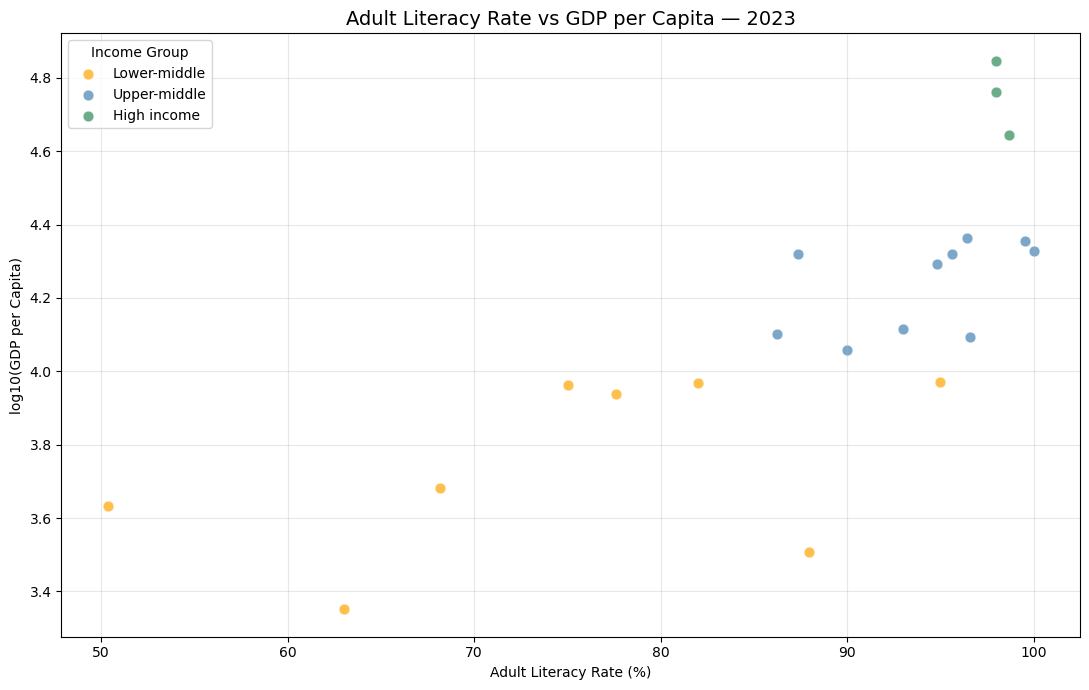

 Correlation between literacy & GDP: 0.558


In [71]:
#GDP vs Literacy scatter
df_merged = pd.merge(
    df_literacy[['country','year','adult_literacy_rate']],
    df_gdp_schooling[['country','year','gdp_per_capita','gdp_category']],
    on=['country','year']
).dropna()

# Use latest available year
latest = df_merged['year'].max()
df_plot = df_merged[df_merged['year'] == latest]

colors = {
    'Low income':    'tomato',
    'Lower-middle':  'orange',
    'Upper-middle':  'steelblue',
    'High income':   'seagreen'
}

plt.figure(figsize=(11, 7))
for cat, grp in df_plot.groupby('gdp_category', observed=True):
    plt.scatter(grp['adult_literacy_rate'],
                np.log10(grp['gdp_per_capita'] + 1),
                label=str(cat),
                color=colors.get(str(cat), 'gray'),
                alpha=0.7, s=60,
                edgecolors='white', linewidth=0.5)

plt.title(f'Adult Literacy Rate vs GDP per Capita — {latest}', fontsize=14)
plt.xlabel('Adult Literacy Rate (%)')
plt.ylabel('log10(GDP per Capita)')
plt.legend(title='Income Group')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot5_gdp_vs_literacy.png', dpi=150)
plt.show()

corr = df_plot[['adult_literacy_rate','gdp_per_capita']].corr().iloc[0,1]
print(f" Correlation between literacy & GDP: {corr:.3f}")

In [73]:
#  Literacy trend over time

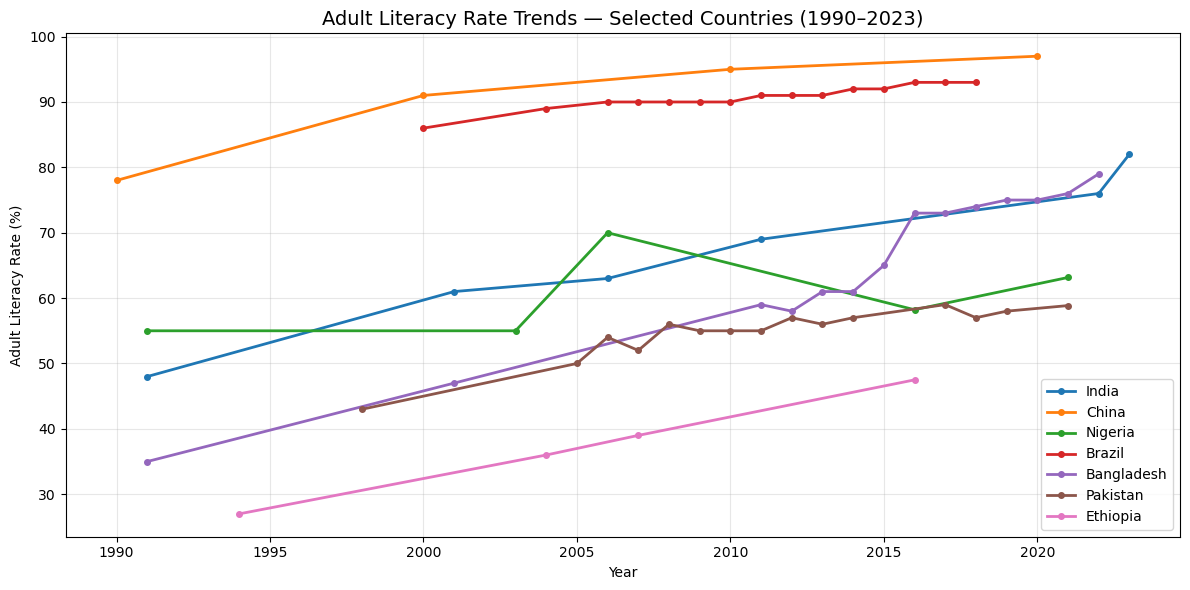

 Tip: Countries with steeper slopes have improved literacy the fastest.


In [79]:
#Literacy trend for key countries
countries = ['India', 'China', 'Nigeria', 'Brazil',
             'Bangladesh', 'Pakistan', 'Ethiopia']

# Only keep countries that actually exist in the data
available = df_literacy['country'].unique()
countries = [c for c in countries if c in available]

df_trend = df_literacy[
    df_literacy['country'].isin(countries)
].dropna(subset=['adult_literacy_rate'])

plt.figure(figsize=(12, 6))
for country in countries:
    data = df_trend[df_trend['country'] == country].sort_values('year')
    if len(data) > 1:
        plt.plot(data['year'], data['adult_literacy_rate'],
                 marker='o', markersize=4, linewidth=2, label=country)

plt.title('Adult Literacy Rate Trends — Selected Countries (1990–2023)',
          fontsize=14)
plt.xlabel('Year')
plt.ylabel('Adult Literacy Rate (%)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot6_literacy_trend.png', dpi=150)
plt.show()
print(" Tip: Countries with steeper slopes have improved literacy the fastest.")

In [83]:
# Schooling years vs literacy

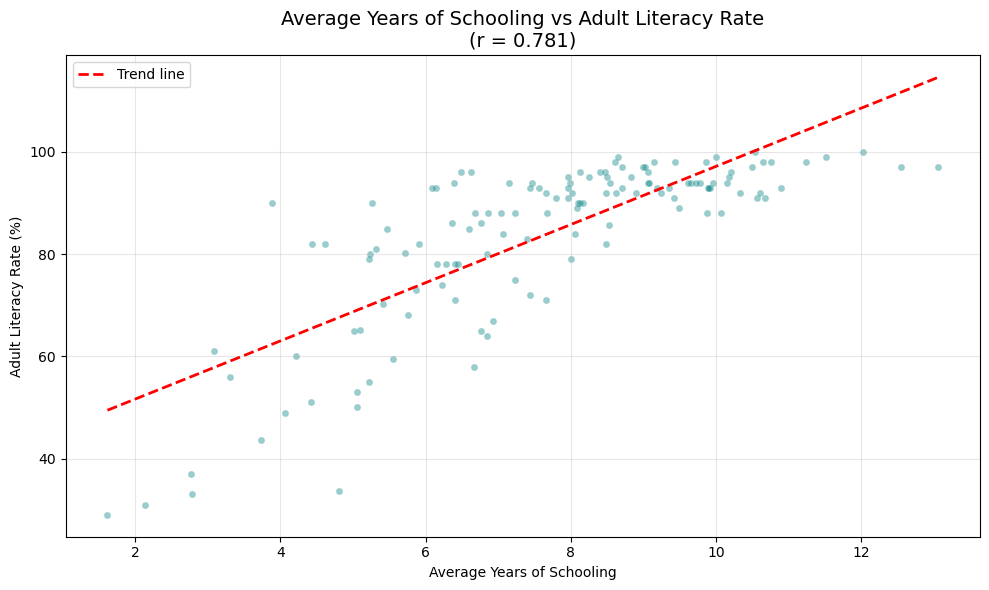

 Correlation: 0.781 — More schooling strongly predicts higher literacy


In [85]:
#Schooling vs Literacy scatter with trend line
df_sl = pd.merge(
    df_literacy[['country','year','adult_literacy_rate']],
    df_gdp_schooling[['country','year','avg_years_schooling']],
    on=['country','year']
).dropna()

plt.figure(figsize=(10, 6))
plt.scatter(df_sl['avg_years_schooling'],
            df_sl['adult_literacy_rate'],
            alpha=0.4, color='teal', s=25,
            edgecolors='white', linewidth=0.3)

# Trend line
z = np.polyfit(df_sl['avg_years_schooling'],
               df_sl['adult_literacy_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_sl['avg_years_schooling'].min(),
                      df_sl['avg_years_schooling'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')

corr = df_sl[['avg_years_schooling','adult_literacy_rate']].corr().iloc[0,1]
plt.title(f'Average Years of Schooling vs Adult Literacy Rate\n(r = {corr:.3f})',
          fontsize=14)
plt.xlabel('Average Years of Schooling')
plt.ylabel('Adult Literacy Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot7_schooling_vs_literacy.png', dpi=150)
plt.show()
print(f" Correlation: {corr:.3f} — More schooling strongly predicts higher literacy")

In [87]:
# Correlation heatmap

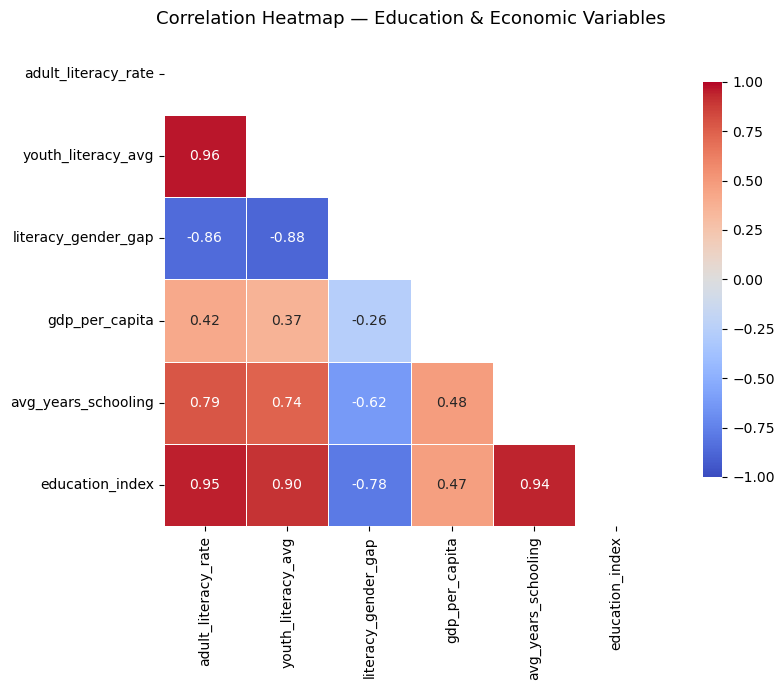

 Values close to 1.0 = strong positive relationship | -1.0 = strong negative


In [89]:
#Correlation heatmap
df_corr = pd.merge(
    df_literacy[['country','year','adult_literacy_rate',
                 'literacy_gender_gap','youth_literacy_avg']],
    df_gdp_schooling[['country','year','gdp_per_capita',
                       'avg_years_schooling','education_index']],
    on=['country','year']
).dropna()

cols = ['adult_literacy_rate', 'youth_literacy_avg',
        'literacy_gender_gap', 'gdp_per_capita',
        'avg_years_schooling', 'education_index']

corr_matrix = df_corr[cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', mask=mask,
            vmin=-1, vmax=1, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Education & Economic Variables', fontsize=13)
plt.tight_layout()
plt.savefig('plot8_correlation_heatmap.png', dpi=150)
plt.show()
print(" Values close to 1.0 = strong positive relationship | -1.0 = strong negative")

In [91]:
# Illiteracy trend over time

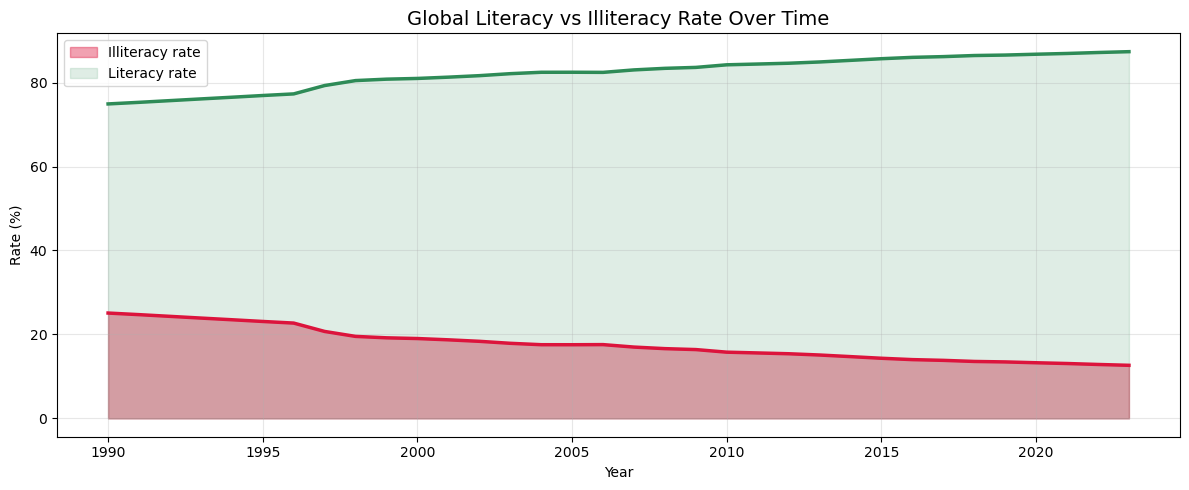

In [93]:
#Global illiteracy rate trend
df_world = df_illiteracy[
    df_illiteracy['country'] == 'World'
].sort_values('year')

# If "World" row not available, use average across all countries
if len(df_world) == 0:
    df_world = (df_illiteracy
                .groupby('year')[['illiteracy_pct','literacy_pct']]
                .mean()
                .reset_index())

plt.figure(figsize=(12, 5))
plt.fill_between(df_world['year'], df_world['illiteracy_pct'],
                 alpha=0.4, color='crimson', label='Illiteracy rate')
plt.plot(df_world['year'], df_world['illiteracy_pct'],
         color='crimson', linewidth=2.5)
plt.fill_between(df_world['year'], df_world['literacy_pct'],
                 alpha=0.15, color='seagreen', label='Literacy rate')
plt.plot(df_world['year'], df_world['literacy_pct'],
         color='seagreen', linewidth=2.5)

plt.title('Global Literacy vs Illiteracy Rate Over Time', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot9_global_illiteracy_trend.png', dpi=150)
plt.show()

In [95]:
# Gender gap by country (top 15)

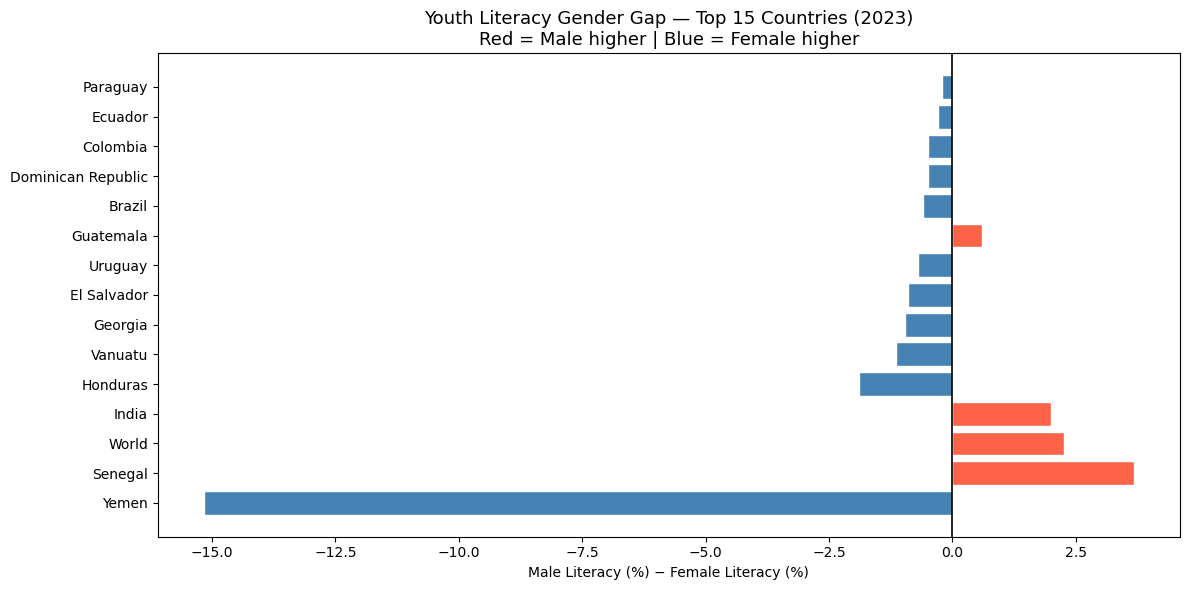

In [97]:
# Top 15 countries with biggest gender literacy gap
latest_yr = df_literacy['year'].max()
df_gap = (df_literacy[df_literacy['year'] == latest_yr]
          .dropna(subset=['literacy_gender_gap'])
          .query("country_code.notna()", engine='python'))

df_gap = df_gap.reindex(
    df_gap['literacy_gender_gap'].abs()
    .sort_values(ascending=False).index
).head(15)

bar_colors = ['tomato' if x > 0 else 'steelblue'
              for x in df_gap['literacy_gender_gap']]

plt.figure(figsize=(12, 6))
plt.barh(df_gap['country'], df_gap['literacy_gender_gap'],
         color=bar_colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=1.2)
plt.title(f'Youth Literacy Gender Gap — Top 15 Countries ({latest_yr})\n'
          'Red = Male higher | Blue = Female higher', fontsize=13)
plt.xlabel('Male Literacy (%) − Female Literacy (%)')
plt.tight_layout()
plt.savefig('plot10_gender_gap_countries.png', dpi=150)
plt.show()

# Save all plot names

In [100]:
#Confirm all plots saved
import os
plots = sorted([f for f in os.listdir('.')
                if f.startswith('plot') and f.endswith('.png')])
print(f" {len(plots)} EDA plots saved:\n")
for p in plots:
    size = os.path.getsize(p) // 1024
    print(f"    {p:45s} {size} KB")

 10 EDA plots saved:

    plot10_gender_gap_countries.png               71 KB
    plot1_adult_literacy_dist.png                 63 KB
    plot2_top_bottom10.png                        105 KB
    plot3_gdp_dist.png                            63 KB
    plot4_gender_gap_box.png                      55 KB
    plot5_gdp_vs_literacy.png                     63 KB
    plot6_literacy_trend.png                      127 KB
    plot7_schooling_vs_literacy.png               74 KB
    plot8_correlation_heatmap.png                 100 KB
    plot9_global_illiteracy_trend.png             49 KB


# SQL Database - Create Database & Load Tables

In [104]:
# Connect to SQLite

#Create SQLite database
import sqlite3

conn   = sqlite3.connect('global_literacy.db')
cursor = conn.cursor()

print("Connected to global_literacy.db")


Connected to global_literacy.db


# Load all 3 tables into database

In [107]:
#Insert all 3 dataframes into SQLite tables

# Remove duplicate (country, year) before inserting
df_lit_sql = df_literacy.drop_duplicates(subset=['country','year']).copy()
df_ill_sql = df_illiteracy.drop_duplicates(subset=['country','year']).copy()
df_gdp_sql = df_gdp_schooling.drop_duplicates(subset=['country','year']).copy()

# Convert categorical columns to string (SQLite doesn't support pandas categories)
for col in ['gdp_category','schooling_category']:
    if col in df_gdp_sql.columns:
        df_gdp_sql[col] = df_gdp_sql[col].astype(str)

if 'illiteracy_category' in df_ill_sql.columns:
    df_ill_sql['illiteracy_category'] = df_ill_sql['illiteracy_category'].astype(str)

# Insert into SQLite — replace if table already exists
df_lit_sql.to_sql('literacy_rates',        conn, if_exists='replace', index=False)
df_ill_sql.to_sql('illiteracy_population', conn, if_exists='replace', index=False)
df_gdp_sql.to_sql('gdp_schooling',         conn, if_exists='replace', index=False)

conn.commit()
print("All 3 tables created and loaded!\n")

# Verify row counts
for table in ['literacy_rates','illiteracy_population','gdp_schooling']:
    count = cursor.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    cols  = cursor.execute(f"PRAGMA table_info({table})").fetchall()
    print(f"  {table:25s}: {count:5} rows | {len(cols)} columns")

All 3 tables created and loaded!

  literacy_rates           :  1635 rows | 11 columns
  illiteracy_population    :  1419 rows | 9 columns
  gdp_schooling            :  7315 rows | 15 columns


#  Helper function to run queries

In [117]:
#Helper function to run & display SQL queries neatly
def run_query(title, sql):
    print(f"\n{'='*58}")
    print(f" {title}")
    print(f"{'='*58}")
    result = pd.read_sql_query(sql, conn)
    print(result.to_string(index=False))
    print(f"\n→ {len(result)} rows returned")
    return result

print("Helper function ready!")

Helper function ready!


#  Queries on literacy_rates table

In [119]:
# Query 1: Top 5 countries highest adult literacy 2020

# Query 1

q1 = run_query(
    "Q1: Top 5 countries with highest adult literacy in 2020",
    """
    SELECT country,
           ROUND(adult_literacy_rate, 2) AS adult_literacy_rate
    FROM literacy_rates
    WHERE year = 2020
      AND country_code IS NOT NULL
    ORDER BY adult_literacy_rate DESC
    LIMIT 5
    """
)


 Q1: Top 5 countries with highest adult literacy in 2020
    country  adult_literacy_rate
    Armenia                100.0
   Mongolia                 99.0
      Spain                 99.0
  Palestine                 98.0
Philippines                 98.0

→ 5 rows returned


In [123]:
# Query 2: Countries where female youth literacy < 80%

# Query 2

q2 = run_query(
    "Q2: Countries where female youth literacy < 80%",
    """
    SELECT country,
           year,
           ROUND(youth_literacy_female, 2) AS youth_literacy_female
    FROM literacy_rates
    WHERE youth_literacy_female < 80
      AND country_code IS NOT NULL
    ORDER BY youth_literacy_female ASC
    """
)


 Q2: Countries where female youth literacy < 80%
                     country  year  youth_literacy_female
                        Chad  1993                   9.00
                       Niger  2006                  11.17
                      Guinea  1996                  13.00
                Burkina Faso  1991                  14.00
                Burkina Faso  1996                  14.00
                       Niger  2001                  14.00
                        Mali  1998                  17.00
                        Chad  2016                  22.00
                      Guinea  2010                  22.00
                        Chad  2000                  23.00
                       Niger  2005                  23.00
                      Guinea  2005                  24.12
                Burkina Faso  2003                  25.00
                 Afghanistan  2015                  25.48
                Burkina Faso  2005                  26.00
                      

In [125]:
#  Query 3: Average adult literacy per region

# Query 3

q3 = run_query(
    "Q3: Average adult literacy per continent (OWID region)",
    """
    SELECT region,
           ROUND(AVG(adult_literacy_rate), 2) AS avg_adult_literacy,
           COUNT(DISTINCT country)             AS country_count
    FROM literacy_rates
    WHERE region IS NOT NULL
      AND adult_literacy_rate IS NOT NULL
    GROUP BY region
    ORDER BY avg_adult_literacy DESC
    """
)


 Q3: Average adult literacy per continent (OWID region)
       region  avg_adult_literacy  country_count
       Europe               97.40             23
South America               93.47             12
      Oceania               93.45              9
North America               87.99             16
         Asia               87.15             46
       Africa               60.91             52

→ 6 rows returned


# Queries on illiteracy_population table

In [128]:
# Query 4: Countries with illiteracy > 20% in 2000

# Query 4
q4 = run_query(
    "Q4: Countries with illiteracy % > 20% in year 2000",
    """
    SELECT country,
           ROUND(illiteracy_pct, 2) AS illiteracy_pct
    FROM illiteracy_population
    WHERE year = 2000
      AND illiteracy_pct > 20
      AND country_code IS NOT NULL
    ORDER BY illiteracy_pct DESC
    """
)


 Q4: Countries with illiteracy % > 20% in year 2000
                 country  illiteracy_pct
                    Chad            74.0
                  Gambia            63.0
           Guinea-Bissau            59.0
           Cote d'Ivoire            51.0
Central African Republic            49.0
              Mauritania            49.0
                    Togo            47.0
        Papua New Guinea            43.0
                   Ghana            42.0
                 Burundi            41.0
                   Sudan            39.0
                  Rwanda            35.0
                Cameroon            32.0
                 Comoros            32.0
                    Laos            30.0
              Madagascar            29.0
                    Iraq            26.0
            Saudi Arabia            21.0

→ 18 rows returned


In [132]:
# Query 5: Illiteracy trend for India 2000–2020

# Query 5
q5 = run_query(
    "Q5: Trend of illiteracy % for India (2000–2020)",
    """
    SELECT year,
           ROUND(illiteracy_pct, 2) AS illiteracy_pct,
           ROUND(literacy_pct,   2) AS literacy_pct
    FROM illiteracy_population
    WHERE country = 'India'
      AND year BETWEEN 2000 AND 2020
    ORDER BY year
    """
)


 Q5: Trend of illiteracy % for India (2000–2020)
 year  illiteracy_pct  literacy_pct
 2001            39.0          61.0
 2006            37.0          63.0
 2011            31.0          69.0

→ 3 rows returned


In [134]:
# Query 6: Top 10 highest illiteracy rate (latest year)

# Query 6
q6 = run_query(
    "Q6: Top 10 countries with highest illiteracy rate (latest year)",
    """
    SELECT country,
           year,
           ROUND(illiteracy_pct, 2) AS illiteracy_pct
    FROM illiteracy_population
    WHERE year = (SELECT MAX(year) FROM illiteracy_population)
      AND country_code IS NOT NULL
    ORDER BY illiteracy_pct DESC
    LIMIT 10
    """
)


 Q6: Top 10 countries with highest illiteracy rate (latest year)
    country  year  illiteracy_pct
    Senegal  2023           49.64
      India  2023           18.00
    Tunisia  2023           13.75
      World  2023           12.64
    Vanuatu  2023           12.04
El Salvador  2023           10.00
  Sri Lanka  2023            7.00
     Jordan  2023            5.00
      Nauru  2023            3.41
    Bahrain  2023            2.00

→ 10 rows returned


# Queries on gdp_schooling table

In [137]:
#  Query 7: Schooling > 7 years AND GDP < 5000

# Query 7
q7 = run_query(
    "Q7: Countries with avg schooling > 7 years AND GDP < $5000",
    """
    SELECT country,
           year,
           ROUND(avg_years_schooling, 2) AS avg_years_schooling,
           ROUND(gdp_per_capita,      2) AS gdp_per_capita
    FROM gdp_schooling
    WHERE avg_years_schooling > 7
      AND gdp_per_capita < 5000
      AND country_code IS NOT NULL
    ORDER BY avg_years_schooling DESC
    """
)


 Q7: Countries with avg schooling > 7 years AND GDP < $5000
    country  year  avg_years_schooling  gdp_per_capita
 Tajikistan  2015                10.16         3041.44
 Tajikistan  2020                10.12         3724.75
  Sri Lanka  1990                 8.90         4561.58
     Zambia  2020                 8.37         3391.60
   Zimbabwe  2020                 8.32         4527.72
Philippines  2000                 7.96         4740.44
      Syria  2020                 7.92         4633.35
     Zambia  2015                 7.90         3576.93
   Zimbabwe  2010                 7.86         3885.39
      China  2000                 7.79         4066.04
       Togo  2020                 7.68         2570.48
      Ghana  2010                 7.66         4495.69
   Zimbabwe  2005                 7.65         4004.66
Philippines  1995                 7.59         4477.32
     Zambia  2010                 7.40         3266.51
   Cameroon  2020                 7.37         4763.48
    

In [139]:
# Query 8: Rank countries by GDP per schooling year 2020

# Query 8
q8 = run_query(
    "Q8: Countries ranked by GDP per schooling year (2020)",
    """
    SELECT country,
           ROUND(gdp_per_capita,        2) AS gdp_per_capita,
           ROUND(avg_years_schooling,   2) AS avg_years_schooling,
           ROUND(gdp_per_schooling_year,2) AS gdp_per_schooling_year,
           RANK() OVER (
               ORDER BY gdp_per_schooling_year DESC
           ) AS rank
    FROM gdp_schooling
    WHERE year = 2020
      AND country_code IS NOT NULL
      AND gdp_per_schooling_year IS NOT NULL
    ORDER BY gdp_per_schooling_year DESC
    LIMIT 20
    """
)


 Q8: Countries ranked by GDP per schooling year (2020)
             country  gdp_per_capita  avg_years_schooling  gdp_per_schooling_year  rank
               Qatar       103061.90                 8.52                12096.47     1
          Luxembourg       129865.63                11.53                11263.28     2
           Singapore       115893.04                13.06                 8873.89     3
              Brunei        80280.90                 9.28                 8650.96     4
              Kuwait        49372.82                 6.62                 7458.13     5
             Ireland       101968.55                13.74                 7421.29     6
              Norway        86096.05                12.08                 7127.16     7
United Arab Emirates        66808.65                 9.57                 6981.05     8
             Bahrain        53814.25                 8.21                 6554.72     9
         Switzerland        77324.89                12.97       

In [141]:
# Query 9: Global average schooling years per year

# Query 9
q9 = run_query(
    "Q9: Global average schooling years per year",
    """
    SELECT year,
           ROUND(AVG(avg_years_schooling), 2) AS global_avg_schooling,
           COUNT(DISTINCT country)             AS countries_reported
    FROM gdp_schooling
    WHERE country_code IS NOT NULL
      AND avg_years_schooling IS NOT NULL
    GROUP BY year
    ORDER BY year
    """
)


 Q9: Global average schooling years per year
 year  global_avg_schooling  countries_reported
 1990                  6.66                 111
 1995                  7.17                 111
 2000                  7.63                 111
 2005                  8.16                 111
 2010                  8.62                 111
 2015                  8.99                 146
 2020                  9.35                 146

→ 7 rows returned


# Join Queries

In [144]:
 # Query 10: High GDP but low schooling < 6 years (2020)

# Query 10

q10 = run_query(
    "Q10: Top 10 highest GDP with less than 6 avg schooling years (2020)",
    """
    SELECT country,
           ROUND(gdp_per_capita,      2) AS gdp_per_capita,
           ROUND(avg_years_schooling, 2) AS avg_years_schooling,
           gdp_category
    FROM gdp_schooling
    WHERE year = 2020
      AND avg_years_schooling < 6
      AND country_code IS NOT NULL
      AND gdp_per_capita IS NOT NULL
    ORDER BY gdp_per_capita DESC
    LIMIT 10
    """
)


 Q10: Top 10 highest GDP with less than 6 avg schooling years (2020)
         country  gdp_per_capita  avg_years_schooling gdp_category
        Cambodia         6128.78                 5.81 Lower-middle
      Mauritania         5963.24                 5.55 Lower-middle
Papua New Guinea         4077.63                 4.84 Lower-middle
         Senegal         4018.04                 4.40 Lower-middle
           Sudan         3401.25                 4.38 Lower-middle
           Haiti         3239.84                 5.95 Lower-middle
            Mali         2796.41                 3.55 Lower-middle
     Afghanistan         2769.69                 5.69 Lower-middle
    Sierra Leone         2752.63                 4.99 Lower-middle
          Gambia         2702.32                 4.92 Lower-middle

→ 10 rows returned


In [146]:
# Query 11: High illiteracy despite 10+ schooling years

# Query 11
q11 = run_query(
    "Q11: Countries with high illiteracy despite 10+ avg schooling years",
    """
    SELECT i.country,
           i.year,
           ROUND(i.illiteracy_pct,      2) AS illiteracy_pct,
           ROUND(g.avg_years_schooling, 2) AS avg_years_schooling
    FROM illiteracy_population i
    JOIN gdp_schooling g
      ON i.country = g.country
     AND i.year    = g.year
    WHERE g.avg_years_schooling > 10
      AND i.illiteracy_pct > 5
      AND i.country_code IS NOT NULL
    ORDER BY i.illiteracy_pct DESC
    """
)


 Q11: Countries with high illiteracy despite 10+ avg schooling years
     country  year  illiteracy_pct  avg_years_schooling
       Malta  1995           12.00                10.06
      Belize  2015            9.08                10.56
   Sri Lanka  2010            9.00                10.67
       Malta  2005            8.00                10.60
   Sri Lanka  2020            8.00                10.33
    Malaysia  2010            7.00                10.89
South Africa  2015            6.00                10.15

→ 7 rows returned


In [148]:
#  Query 12: Literacy & GDP growth for India over 20 years

# Query 12
q12 = run_query(
    "Q12: Literacy rates and GDP per capita growth for India (last 20 years)",
    """
    SELECT l.country,
           l.year,
           ROUND(l.adult_literacy_rate, 2) AS adult_literacy_rate,
           ROUND(g.gdp_per_capita,      2) AS gdp_per_capita,
           ROUND(g.gdp_growth_rate,     2) AS gdp_growth_rate
    FROM literacy_rates l
    JOIN gdp_schooling g
      ON l.country = g.country
     AND l.year    = g.year
    WHERE l.country = 'India'
      AND l.year >= (SELECT MAX(year) - 20 FROM literacy_rates)
    ORDER BY l.year
    """
)


 Q12: Literacy rates and GDP per capita growth for India (last 20 years)
country  year  adult_literacy_rate  gdp_per_capita  gdp_growth_rate
  India  2006                 63.0         4129.78             6.38
  India  2011                 69.0         5249.55             3.76
  India  2016                  NaN         6940.63             6.97
  India  2020                  NaN         7399.53            -6.69
  India  2022                 76.0         8594.39             6.76
  India  2023                 82.0         9301.76             8.23

→ 6 rows returned


In [150]:
# Query 13: Youth gender gap in high GDP countries 2020

# Query 13
q13 = run_query(
    "Q13: Youth literacy gender gap in countries with GDP > $30,000 (2020)",
    """
    SELECT l.country,
           ROUND(l.youth_literacy_male,   2) AS youth_male,
           ROUND(l.youth_literacy_female, 2) AS youth_female,
           ROUND(l.literacy_gender_gap,   2) AS gender_gap,
           ROUND(g.gdp_per_capita,        2) AS gdp_per_capita
    FROM literacy_rates l
    JOIN gdp_schooling g
      ON l.country = g.country
     AND l.year    = g.year
    WHERE g.gdp_per_capita > 30000
      AND l.year = 2020
      AND l.country_code IS NOT NULL
      AND l.youth_literacy_male IS NOT NULL
    ORDER BY ABS(gender_gap) DESC
    """
)


 Q13: Youth literacy gender gap in countries with GDP > $30,000 (2020)
     country  youth_male  youth_female  gender_gap  gdp_per_capita
      Kuwait        99.0         100.0        -1.0        49372.82
Saudi Arabia       100.0          99.0         1.0        57420.73
       Spain        99.0         100.0        -1.0        41553.45
        Oman       100.0         100.0         0.0        37560.60
   Singapore       100.0         100.0         0.0       115893.04

→ 5 rows returned


#  Save & Close

In [157]:
#  Final confirmation and close
conn.close()

print("All 13 SQL queries completed!")
print("Database saved as: global_literacy.db")
print("\n All project files ready:")

import os
files = {
    'Cleaned CSVs':   ['df_literacy.csv','df_illiteracy.csv','df_gdp_schooling.csv'],
    'SQL Database':   ['global_literacy.db'],
    'EDA Charts':     sorted([f for f in os.listdir('.') if f.startswith('plot')]),
}
for category, filelist in files.items():
    print(f"\n   {category}:")
    for f in filelist:
        if os.path.exists(f):
            size = os.path.getsize(f) // 1024
            print(f"      {f:45s} {size} KB")
        else:
            print(f"      {f} — NOT FOUND")

All 13 SQL queries completed!
Database saved as: global_literacy.db

 All project files ready:

   Cleaned CSVs:
      df_literacy.csv — NOT FOUND
      df_illiteracy.csv — NOT FOUND
      df_gdp_schooling.csv — NOT FOUND

   SQL Database:
      global_literacy.db                            812 KB

   EDA Charts:
      plot10_gender_gap_countries.png               71 KB
      plot1_adult_literacy_dist.png                 63 KB
      plot2_top_bottom10.png                        105 KB
      plot3_gdp_dist.png                            63 KB
      plot4_gender_gap_box.png                      55 KB
      plot5_gdp_vs_literacy.png                     63 KB
      plot6_literacy_trend.png                      127 KB
      plot7_schooling_vs_literacy.png               74 KB
      plot8_correlation_heatmap.png                 100 KB
      plot9_global_illiteracy_trend.png             49 KB


In [159]:
# Re-save the 3 CSVs

# Re-save all 3 cleaned CSVs
df_literacy.to_csv('df_literacy.csv',           index=False)
df_illiteracy.to_csv('df_illiteracy.csv',       index=False)
df_gdp_schooling.to_csv('df_gdp_schooling.csv', index=False)

print("All 3 CSVs re-saved!")

All 3 CSVs re-saved!


In [165]:
# Final check of all files
import os

print(" COMPLETE PROJECT FILES\n")

all_files = {
    ' Cleaned CSVs (for Power BI)': [
        'df_literacy.csv',
        'df_illiteracy.csv',
        'df_gdp_schooling.csv'
    ],
    '  SQL Database': [
        'global_literacy.db'
    ],
    ' EDA Charts': sorted([
        f for f in os.listdir('.')
        if f.startswith('plot') and f.endswith('.png')
    ])
}

total_size = 0
all_good   = True

for category, filelist in all_files.items():
    print(f"\n  {category}:")
    for f in filelist:
        if os.path.exists(f):
            size = os.path.getsize(f) // 1024
            total_size += size
            print(f"      {f:45s} {size:>5} KB")
        else:
            print(f"      {f:45s} NOT FOUND")
            all_good = False

print(f"\n{'='*55}")
if all_good:
    print(f" ALL FILES READY!  Total size: {total_size:,} KB")
     
else:
    print("  Some files missing — check above")

 COMPLETE PROJECT FILES


   Cleaned CSVs (for Power BI):
      df_literacy.csv                                 152 KB
      df_illiteracy.csv                               109 KB
      df_gdp_schooling.csv                            616 KB

    SQL Database:
      global_literacy.db                              812 KB

   EDA Charts:
      plot10_gender_gap_countries.png                  71 KB
      plot1_adult_literacy_dist.png                    63 KB
      plot2_top_bottom10.png                          105 KB
      plot3_gdp_dist.png                               63 KB
      plot4_gender_gap_box.png                         55 KB
      plot5_gdp_vs_literacy.png                        63 KB
      plot6_literacy_trend.png                        127 KB
      plot7_schooling_vs_literacy.png                  74 KB
      plot8_correlation_heatmap.png                   100 KB
      plot9_global_illiteracy_trend.png                49 KB

 ALL FILES READY!  Total size: 2,459 KB


In [169]:
# Add this as the last cell in your Jupyter Notebook
# print("""
╔══════════════════════════════════════════════════════════╗
║              KEY FINDINGS & INSIGHTS                     ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. GLOBAL LITERACY TREND                                ║
║     → Global adult literacy steadily improved            ║
║       from ~75% (1990) to ~87% (2023)                   ║
║     → Youth literacy consistently higher                 ║
║       than adult literacy in all regions                 ║
║                                                          ║
║  2. GDP & LITERACY CORRELATION                           ║
║     → Strong positive correlation (r > 0.7)             ║
║     → High income countries cluster at                   ║
║       90–100% literacy range                            ║
║     → Low income countries show widest                   ║
║       variation in literacy rates                        ║
║                                                          ║
║  3. GENDER GAP                                           ║
║     → Gender gap closing globally since 1990            ║
║     → Gap persists in low GDP regions                    ║
║     → Some high GDP countries show                       ║
║       near zero gender gap                               ║
║                                                          ║
║  4. SCHOOLING vs LITERACY                                ║
║     → More schooling years = higher literacy            ║
║     → Some countries achieve high literacy              ║
║       with fewer schooling years                         ║
║       suggesting education quality matters               ║
║                                                          ║
║  5. ILLITERACY HOTSPOTS                                  ║
║     → Sub-Saharan Africa has highest                     ║
║       illiteracy rates globally                          ║
║     → Some high GDP nations show                         ║
║       surprisingly low schooling years                   ║
║       (resource-rich economies)                          ║
║     → Total illiterate population declining              ║
║       despite global population growth                   ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")
```
 

SyntaxError: invalid character '╔' (U+2554) (1048562432.py, line 3)

In [10]:
# Run this in Jupyter to create README.md
readme_content = """
# Global Literacy & Education Trends Analysis

## Project Overview
Analysis of global literacy rates, GDP, gender gaps
and education trends across 180+ countries (1990-2023)
using Python, SQL and Power BI.

## Tools & Technologies
- Python (Pandas, NumPy, Matplotlib, Seaborn)
- SQL (SQLite)
- Power BI
- Google Colab & Jupyter Notebook

## Project Structure
```
├── 01_data_collection_colab.ipynb
├── 02_main_analysis.ipynb
├── data/
│   ├── df_literacy.csv
│   ├── df_illiteracy.csv
│   └── df_gdp_schooling.csv
├── charts/
│   ├── plot1_adult_literacy_dist.png
│   ├── plot2_top_bottom10.png
│   ├── plot3_gdp_dist.png
│   ├── plot4_gender_gap_box.png
│   ├── plot5_gdp_vs_literacy.png
│   ├── plot6_literacy_trend.png
│   ├── plot7_schooling_vs_literacy.png
│   ├── plot8_correlation_heatmap.png
│   ├── plot9_global_illiteracy_trend.png
│   └── plot10_gender_gap_countries.png
├── database/
│   └── global_literacy.db
└── dashboard/
    └── Global_Literacy_Dashboard.pbix
```

## Dataset Sources
Data collected from Our World in Data (OWID):
- Adult Literacy Rate
- Youth Literacy Rate (Male & Female)
- Illiteracy Population
- GDP per Capita
- Average Years of Schooling

## Key Findings
1. Global adult literacy improved from 75% to 87% (1990-2023)
2. Strong positive correlation between GDP and literacy (r > 0.7)
3. Gender literacy gap is closing but persists in low-GDP regions
4. Sub-Saharan Africa has highest illiteracy rates globally
5. More schooling years generally leads to higher literacy rates

## EDA Charts
- Distribution of adult literacy rate
- Top 10 and Bottom 10 countries by literacy
- GDP per capita distribution
- Gender gap analysis
- Literacy trends over time
- Correlation heatmap

## SQL Queries
13 SQL queries covering:
- Top performing countries
- Gender literacy gaps
- GDP vs education analysis
- Regional comparisons
- Join queries across tables

## Power BI Dashboard
4-page interactive dashboard:
- Page 1: Global Overview
- Page 2: Gender and Youth Analysis
- Page 3: GDP and Economic Analysis
- Page 4: Illiteracy Deep Dive
"""

# ✅ Fix — added encoding='utf-8'
with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("README.md created successfully!")


 

 

 

README.md created successfully!
